<a href="https://colab.research.google.com/github/dr-koehler-ai/Sepsis-Clinical-Analytics-Project-V1/blob/main/Sepsis_Dashboard_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Sepsis Survival Prediction**

*Objective*

*   To identify clinical characteristics associated with sepsis status and explore their ability to discriminate between patients with and without sepsis.

*Dataset*
*   40336 patients with a total of 1552210 datapoints
*   38 clinical features
*   binary outcome (target variable: sepsis label)


*Workflow*
*   Data cleaning
*   EDA
*   Statistical Analysis
*   Logistic Regression
*   Machine Learning

*Clinical question*

*   Which routinely collected clinical variables differ between ICU patients who develop sepsis and those who do not, and how well do these features discriminate between the two groups?

**Dataset Overview**


*   Number of rows and columns

In [47]:
# Clinical Sepsis Analytics Dashboard (V1)
# =========================================

#Standard library

#Data manipulation
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np

#Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Statistics
from scipy import stats
from statistics import mean, stdev
from math import sqrt

# Data preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.utils import resample

# Data modeling
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay


# =========================
# 1. Dataset Download
# =========================

dataset_path = kagglehub.dataset_download(
    "salikhussaini49/prediction-of-sepsis"
)

dataset_file = Path(dataset_path) / "Dataset.csv"

dataset_raw_df = pd.read_csv(dataset_file)


# =========================
# 2. Load dataset
# =========================
dataset_raw_df = pd.read_csv(
    "/root/.cache/kagglehub/datasets/salikhussaini49/prediction-of-sepsis/versions/2/Dataset.csv"
)

print("\nShape:", dataset_raw_df.shape)
print("\nColumns:", dataset_raw_df.columns.tolist())
print("\nPatients:", dataset_raw_df["Patient_ID"].nunique())

Using Colab cache for faster access to the 'prediction-of-sepsis' dataset.

Shape: (1552210, 44)

Columns: ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']

Patients: 40336


**Missing Value Analysis and Dataset Aggegration**


*   due to the many time points with partial clinical data available there is a high percentage of missing data
*   only columns with less than 90% of missing values or clinical relevant were kept for further analysis
*   data were aggregated to have one dataset per patient, including maximum Sepsis Label (development of Sepsis during stay)
*   Concerning measurement patient level, 69% of Lactate measurements were missing.



In [34]:
# =========================
# 3. Missing Values Analysis
# =========================
missing = dataset_raw_df.isnull().mean().sort_values(ascending=False)
print("\nTop Missing Values:\n", missing.head(15))


clinical_rel_col = [
    'HR', 'Temp', 'MAP', 'Resp',
    'Creatinine', 'Lactate', 'WBC',
    'Platelets', 'O2Sat'
]

good_cols = missing[missing < 0.9].index
final_cols = list(set(good_cols) | set(clinical_rel_col))

dataset_clean = dataset_raw_df[final_cols]

# =========================
# 4. Patient-level aggregation
# =========================
dataset_agg = dataset_clean.groupby("Patient_ID").agg({
    "HR": ["mean", "max"],
    "MAP": ["mean", "min"],
    "O2Sat": ["mean", "min"],
    "Resp": ["mean", "max"],
    "Lactate": ["mean", "max"],
    "Creatinine": ["mean", "max"],
    "WBC": ["mean", "max"],
    "Platelets": ["mean", "min"],
    "Age": "first",
    "Gender": "first",
    "SepsisLabel": "max"
})

# flatten columns
dataset_agg.columns = [
    f"{col[0]}_{col[1]}" if isinstance(col, tuple) else col
    for col in dataset_agg.columns
]

dataset_agg = dataset_agg.rename(columns={"SepsisLabel_max": "SepsisPatient"})


print("\nFinal dataset shape:", dataset_agg.shape)

dataset_agg.head()

# =========================
# Patient-level Missingness
# =========================

features_missingness = [
    "HR_mean",
    "MAP_min",
    "O2Sat_mean",
    "Resp_mean",
    "Lactate_max",
    "Creatinine_max",
    "WBC_max",
    "Platelets_min",
    "Age_first"
]

patient_missingness = (
    dataset_agg[features_missingness]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(1)
)

patient_missingness = patient_missingness.to_frame(
    name="Missing patients (%)"
)

display(patient_missingness)

missingness_by_sepsis = (
    dataset_agg
    .groupby("SepsisPatient")[features_missingness]
    .apply(lambda x: x.isna().mean() * 100)
    .T
)

missingness_by_sepsis.columns = [
    "Non-Sepsis Missing (%)",
    "Sepsis Missing (%)"
]

missingness_by_sepsis["Difference"] = (
    missingness_by_sepsis["Sepsis Missing (%)"]
    - missingness_by_sepsis["Non-Sepsis Missing (%)"]
)

display(
    missingness_by_sepsis
    .sort_values("Difference")
    .round(1)
)


Top Missing Values:
 Bilirubin_direct    0.998074
Fibrinogen          0.993402
TroponinI           0.990477
Bilirubin_total     0.985092
Alkalinephos        0.983932
AST                 0.983776
Lactate             0.973299
PTT                 0.970559
SaO2                0.965494
EtCO2               0.962868
Phosphate           0.959863
HCO3                0.958106
Chloride            0.954603
BaseExcess          0.945790
PaCO2               0.944401
dtype: float64

Final dataset shape: (40336, 19)


,Missing patients (%)
Lactate_max,69.0
WBC_max,6.5
Platelets_min,6.4
Creatinine_max,5.1
MAP_min,0.3
Resp_mean,0.2
O2Sat_mean,0.0
HR_mean,0.0
Age_first,0.0


,Non-Sepsis Missing (%),Sepsis Missing (%),Difference
Lactate_max,71.5,38.0,-33.5
MAP_min,0.3,0.0,-0.3
HR_mean,0.0,0.0,-0.0
Age_first,0.0,0.0,0.0
O2Sat_mean,0.0,0.1,0.0
Resp_mean,0.2,0.5,0.3
Creatinine_max,4.9,6.8,1.8
WBC_max,6.4,8.3,1.9
Platelets_min,6.2,8.3,2.0


In [23]:
dataset_agg = dataset_agg.reset_index()
dataset_agg.to_csv(
    "sepsis_patient_level_dataset.csv",
    index=False
)

import os
print(os.getcwd())

/content


**Data Validation**


*   Continuous clinical variables were reviewed for implausible minimum and maximum values using descriptive statistics. All examined variables were found to be within clinically plausible physiological ranges, and no obvious data entry errors were identified.

In [36]:
# =========================
# 5. Data Validation
# =========================

dataset_agg.describe()

extreme_quantiles = dataset_agg[
    [
        "HR_max",
        "MAP_min",
        "O2Sat_min",
        "Resp_max",
        "Lactate_max",
        "Creatinine_max",
        "WBC_max",
        "Platelets_min"
    ]
].quantile([
    0.001,
    0.01,
    0.99,
    0.999
]).T

display(extreme_quantiles)

extreme_counts = {
    "HR_max > 220": (dataset_agg["HR_max"] > 220).sum(),
    "MAP_min < 30": (dataset_agg["MAP_min"] < 30).sum(),
    "O2Sat_min < 50": (dataset_agg["O2Sat_min"] < 50).sum(),
    "Resp_max > 60": (dataset_agg["Resp_max"] > 60).sum(),
    "Lactate_max > 20": (dataset_agg["Lactate_max"] > 20).sum(),
    "Creatinine_max > 15": (dataset_agg["Creatinine_max"] > 15).sum(),
    "WBC_max > 100": (dataset_agg["WBC_max"] > 100).sum(),
    "Platelets_min < 10": (dataset_agg["Platelets_min"] < 10).sum()
}

pd.Series(extreme_counts)

,0.001,0.010,0.990,0.999
HR_max,54.0,63.00,153.0000,178.00000
MAP_min,22.0,34.00,100.0000,115.38450
O2Sat_min,24.0,62.00,99.0000,100.00000
Resp_max,7.0,16.00,47.0000,83.73600
Lactate_max,0.5,0.67,14.0616,21.46096
Creatinine_max,0.3,0.40,10.7328,18.69282
WBC_max,0.4,3.00,33.6000,83.95800
Platelets_min,9.0,34.00,521.0000,788.24200


,0
HR_max > 220,2
MAP_min < 30,187
O2Sat_min < 50,202
Resp_max > 60,102
Lactate_max > 20,19
Creatinine_max > 15,119
WBC_max > 100,29
Platelets_min < 10,40


Extreme values were reviewed using descriptive statistics and distributional quantiles. Although several variables contained highly extreme observations, these values remained clinically plausible in a critically ill population. Therefore, no observations were excluded solely on the basis of statistical extremity.

**Cohort Analysis**

*   The cohort analysis showed the distribution of patients developing sepsis during ICU stay. This baseline assessment was performed to evaluate outcome balance before comparing physiological characteristics between groups.
*   Of 40336 patients in total
only the minority of 2932 (7.3%) developed a sepsis, while the majority was Non-sepsis patients (37404, 92.7%).
*   Mean age appeared similar between patients with and without sepsis.


Total patients: 40336
Sepsis patients: 2932 (7.3%)
Non-sepsis patients: 37404 (92.7%)


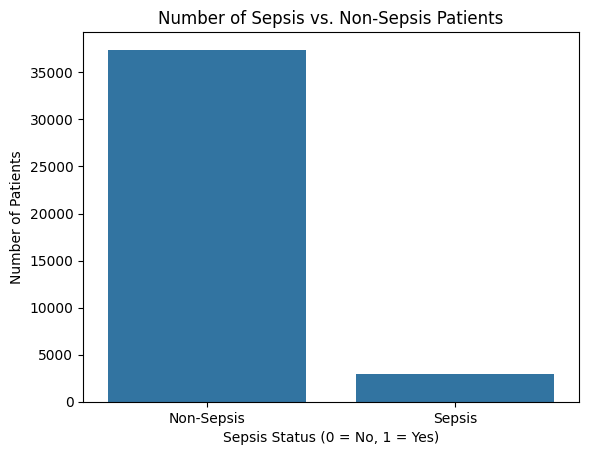

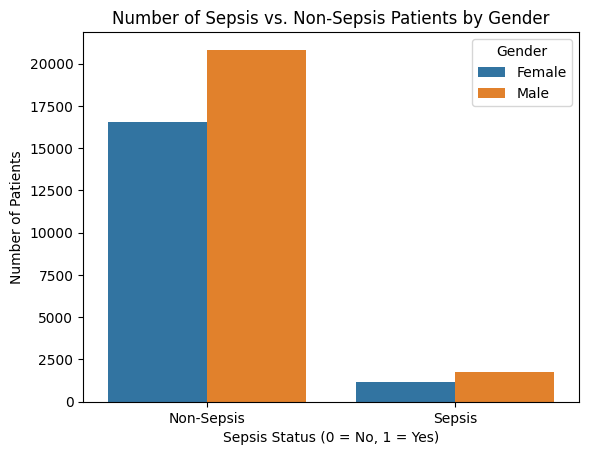

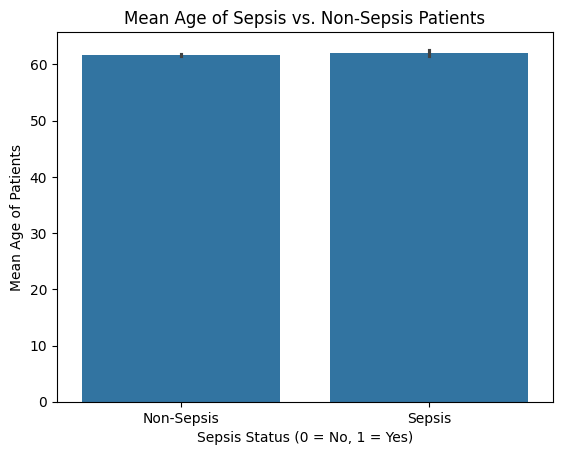

In [25]:
# =========================
# 6. Cohort Analysis
# =========================

total = len(dataset_agg)

sepsis = len(dataset_agg[dataset_agg["SepsisPatient"] == 1])
non_sepsis = len(dataset_agg[dataset_agg["SepsisPatient"] == 0])

print(f"Total patients: {total}")
print(f"Sepsis patients: {sepsis} ({sepsis/total:.1%})")
print(f"Non-sepsis patients: {non_sepsis} ({non_sepsis/total:.1%})")

sns.countplot(data=dataset_agg, x="SepsisPatient")
plt.title ("Number of Sepsis vs. Non-Sepsis Patients")
plt.xlabel("Sepsis Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.xticks(
    ticks=[0,1],
    labels=["Non-Sepsis", "Sepsis"]
)
plt.show()

sns.countplot(data=dataset_agg, x="SepsisPatient", hue="Gender_first")
plt.title ("Number of Sepsis vs. Non-Sepsis Patients by Gender")
plt.xlabel("Sepsis Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.xticks(
    ticks=[0,1],
    labels=["Non-Sepsis", "Sepsis"]
)
plt.legend(
    title="Gender",
    labels=["Female", "Male"]
)
plt.show()

sns.barplot(data=dataset_agg, x="SepsisPatient", y="Age_first", estimator="mean")
plt.title ("Mean Age of Sepsis vs. Non-Sepsis Patients")
plt.xlabel("Sepsis Status (0 = No, 1 = Yes)")
plt.ylabel("Mean Age of Patients")
plt.xticks(
    ticks=[0,1],
    labels=["Non-Sepsis", "Sepsis"]
)
plt.show()

7. **Univariate Analysis**

*Clinical question*:
How are the distributions of key clinical variables within the ICU cohort?

*Objective*:
Assess distribution shape, skewness, variability and potential outliers before comparing sepsis and non-sepsis patients.

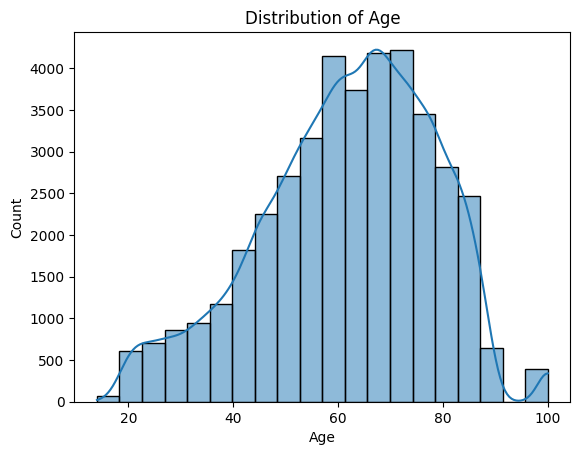

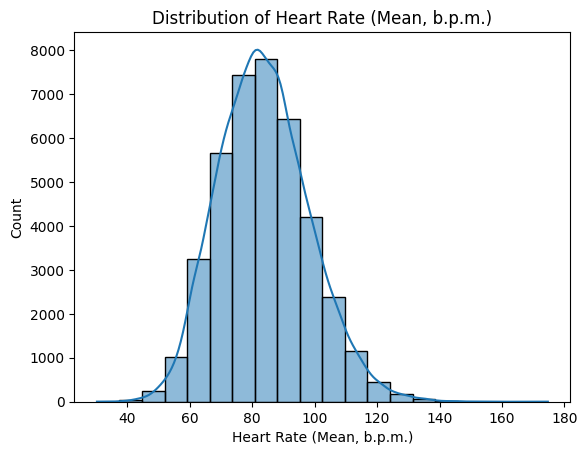

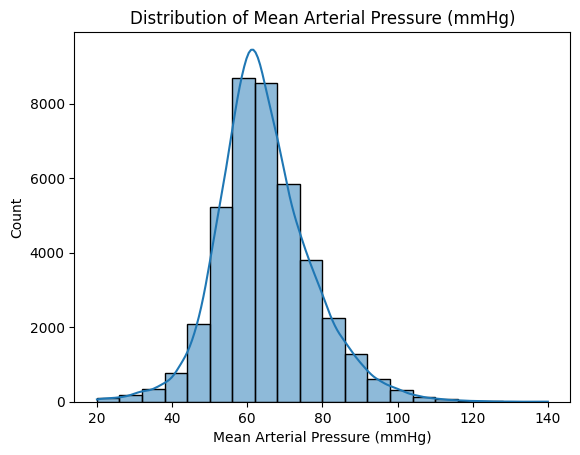

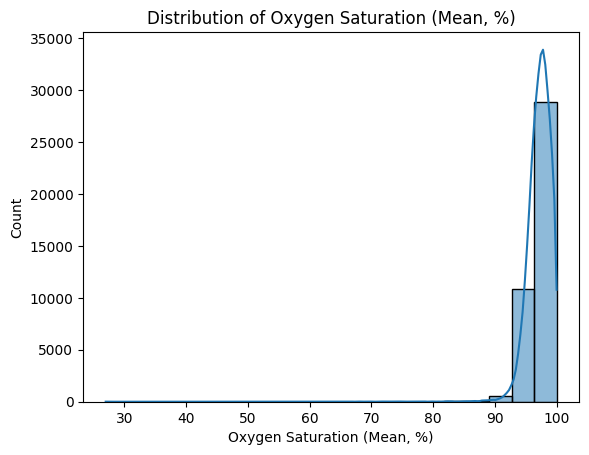

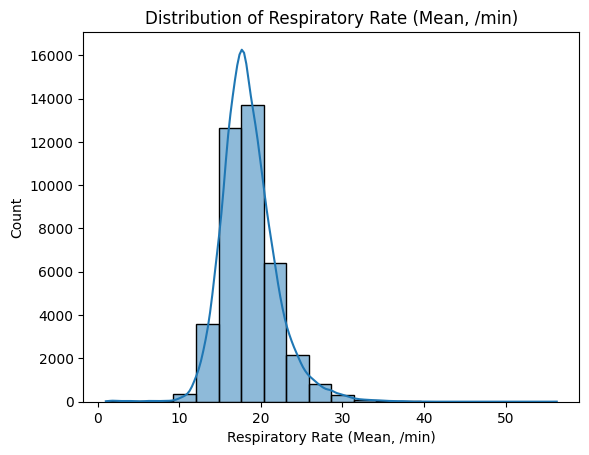

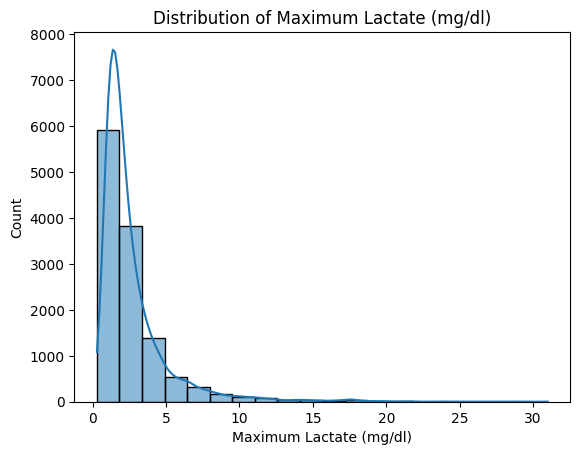

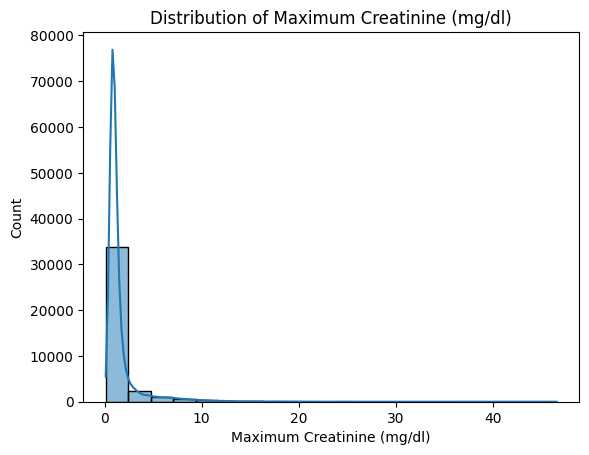

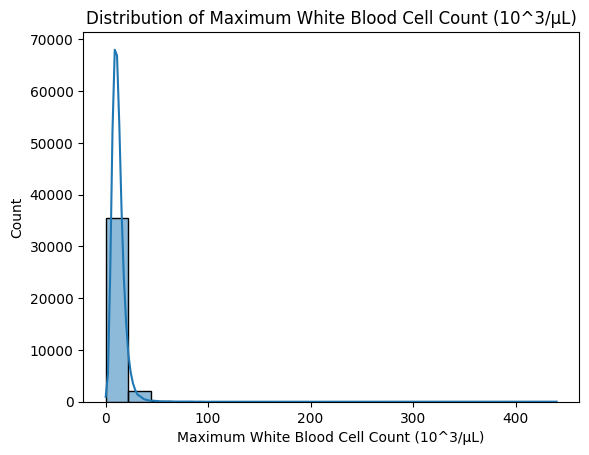

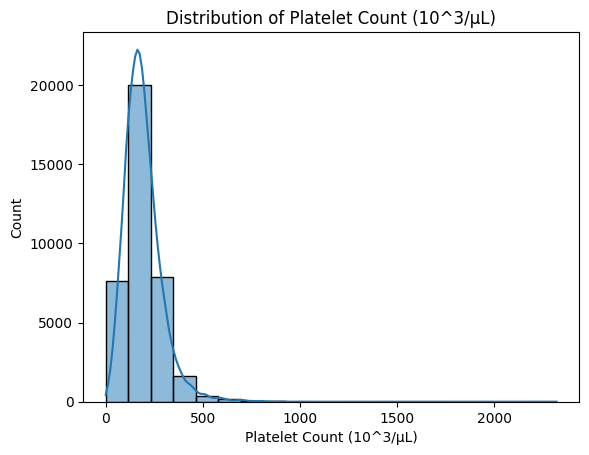

In [39]:
# =========================
# 7. Univeriat Analysis
# =========================

baseline_features = [
    "Age_first",
    "HR_mean",
    "MAP_min",
    "O2Sat_mean",
    "Resp_mean",
    "Lactate_max",
    "Creatinine_max",
    "WBC_max",
    "Platelets_min"
]

variable_labels = {
    "HR_mean": "Heart Rate (Mean, b.p.m.)",
    "MAP_min": "Mean Arterial Pressure (mmHg)",
    "O2Sat_mean": "Oxygen Saturation (Mean, %)",
    "Resp_mean": "Respiratory Rate (Mean, /min)",
    "Lactate_max": "Maximum Lactate (mg/dl)",
    "Creatinine_max": "Maximum Creatinine (mg/dl)",
    "WBC_max": "Maximum White Blood Cell Count (10^3/µL)",
    "Platelets_min": "Platelet Count (10^3/µL)",
    "Age_first": "Age"
}

def var_histogramms(x):
  for feat in x:
    label = variable_labels.get(feat, feat)
    sns.histplot(data=dataset_agg, x=feat, bins= 20, kde=True)
    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.show()
  return

var_histogramms(baseline_features)



*   MAP, Heart rate and age showed a tendency for normal distribution.
*   Platelet and WBC count, serum creatinine and serum Lactate were right skewed, oxygen saturation left skewed.



**Clinical Characteristics by Sepsis Status**

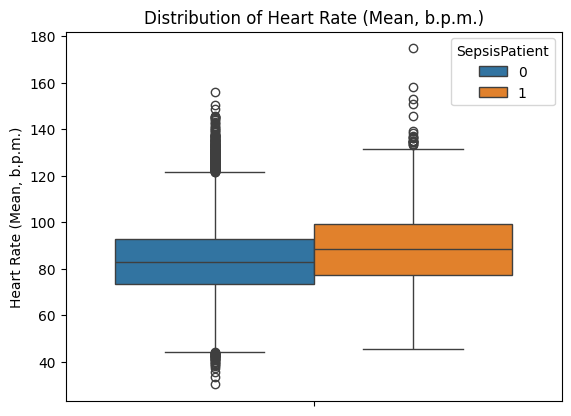

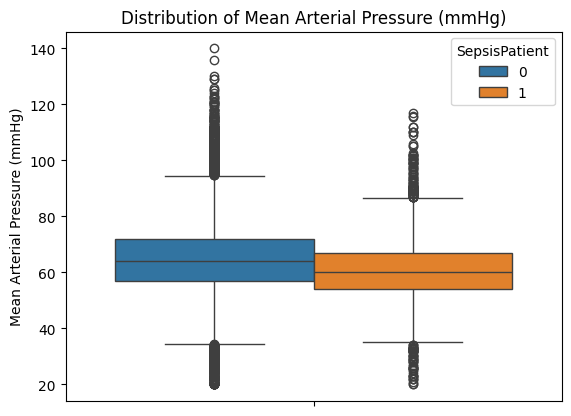

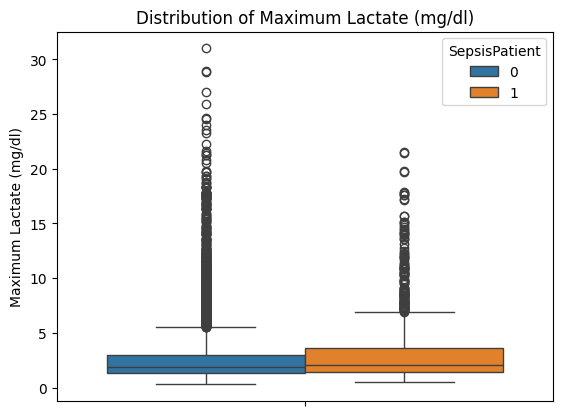

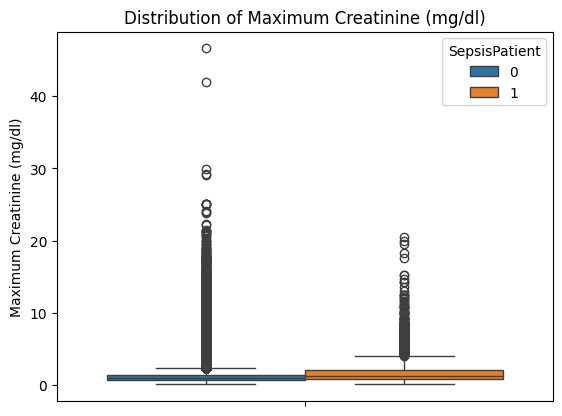

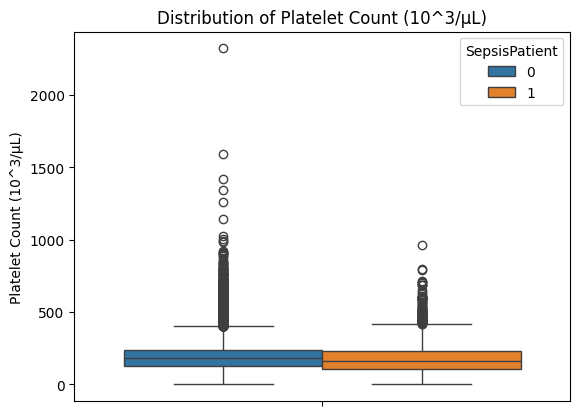

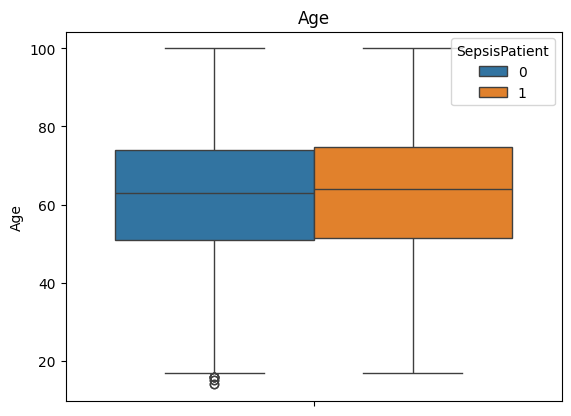

In [40]:
# ===================================================
# 8. Clinical Characteristics by Sepsis Status
# ===================================================

continious_features = [
    "HR_mean",
    "MAP_min",
    "Lactate_max",
    "Creatinine_max",
    "Platelets_min"
]

def var_boxplots(x):
  for feat in x:
    label = variable_labels.get(feat, feat)
    sns.boxplot(data=dataset_agg, y=feat, hue="SepsisPatient")
    plt.title(f"Distribution of {label}")
    plt.ylabel(label)
    plt.show()
  return

var_boxplots(continious_features)

sns.boxplot(data=dataset_agg, y="Age_first", hue="SepsisPatient")
plt.title("Age")
plt.ylabel("Age")
plt.show()

### Key Insights

- Patients with sepsis showed a higher distribution of mean heart rate and lower minimum MAP values compared with non-sepsis patients, suggesting greater cardiovascular and hemodynamic disturbance.
- Maximum lactate and creatinine values tended to be higher among patients with sepsis, although both variables showed substantial overlap and right-skewed distributions.
- Lactate measurements were substantially more frequently available in patients with sepsis; therefore, comparisons of lactate values should be interpreted in the context of potentially informative missingness.
- Minimum platelet counts tended to be lower among patients with sepsis, while age distributions showed considerable overlap between groups.
- Overall, several clinical variables showed descriptive differences between sepsis and non-sepsis patients; statistical testing is required to determine the magnitude and uncertainty of these group differences.

In [41]:
# =========================
# 8. Statistical Analysis
# =========================

continuous_features = [
    "HR_mean",
    "MAP_min",
    "Lactate_max",
    "Creatinine_max",
    "Platelets_min",
    "Age_first"
]

non_normal_features = [
    "Lactate_max",
    "Creatinine_max",
    "Platelets_min"
]

sepsis_patients = dataset_agg[dataset_agg["SepsisPatient"] == 1]
non_sepsis_patients = dataset_agg[dataset_agg["SepsisPatient"] == 0]


def compare_groups(features, test_name="welch"):

    print(f"\n{'='*60}")
    print(f"{test_name.upper()} TEST")
    print(f"{'='*60}")

    for feature in features:

        group1 = sepsis_patients[feature].dropna()
        group2 = non_sepsis_patients[feature].dropna()

        if test_name == "welch":
            statistic, p_value = stats.ttest_ind(
                group1,
                group2,
                equal_var=False
            )

        elif test_name == "mannwhitney":
            statistic, p_value = stats.mannwhitneyu(
                group1,
                group2,
                alternative="two-sided"
            )

        print(
            f"{feature:<20}"
            f"Statistic = {statistic:>10.2f}"
            f"   p = {p_value:.3e}"
        )

def cohens_d(features):

    print(f"\n{'='*60}")
    print("Cohens D")
    print(f"{'='*60}")

    for feature in features:

      group1 = sepsis_patients[feature].dropna()
      group2 = non_sepsis_patients[feature].dropna()

      n1, n2 = len(group1), len(group2)
      var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

      # Pooled standard deviation
      pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

      # Cohen's d formula
      effect_size = (np.mean(group1) - np.mean(group2)) / pooled_std

      print(
            f"{feature:<20}"
            f"Cohens D = {effect_size:>10.2f}"
        )

    return


compare_groups(continuous_features, test_name="welch")
compare_groups(non_normal_features, test_name="mannwhitney")
cohens_d(continuous_features)


WELCH TEST
HR_mean             Statistic =      18.58   p = 2.103e-73
MAP_min             Statistic =     -16.15   p = 1.326e-56
Lactate_max         Statistic =       4.88   p = 1.137e-06
Creatinine_max      Statistic =       9.73   p = 4.394e-22
Platelets_min       Statistic =      -6.45   p = 1.258e-10
Age_first           Statistic =       1.42   p = 1.569e-01

MANNWHITNEY TEST
Lactate_max         Statistic = 10451437.50   p = 1.699e-07
Creatinine_max      Statistic = 58380432.50   p = 4.059e-69
Platelets_min       Statistic = 41761867.00   p = 3.331e-23

Cohens D
HR_mean             Cohens D =       0.39
MAP_min             Cohens D =      -0.31
Lactate_max         Cohens D =       0.13
Creatinine_max      Cohens D =       0.20
Platelets_min       Cohens D =      -0.14
Age_first           Cohens D =       0.03


### Statistical Analysis – Key Findings

Univariate statistical testing identified differences in several clinical variables between patients with and without sepsis.

- **Heart rate** was higher in patients with sepsis (Welch's t-test, p < 0.001), with a small-to-moderate effect size (Cohen's d = 0.39).
- **Minimum MAP** was lower in patients with sepsis (p < 0.001), with a small-to-moderate effect size (Cohen's d = -0.31).
- **Maximum creatinine** was higher in patients with sepsis (p < 0.001), although the effect size was small (Cohen's d = 0.20).
- **Maximum lactate** was higher in patients with sepsis (p < 0.001), but the effect size was small (Cohen's d = 0.13). Interpretation is limited by substantial and outcome-dependent missingness of lactate measurements.
- **Minimum platelet count** was lower in patients with sepsis (p < 0.001), with a small effect size (Cohen's d = -0.14).
- **Age** did not differ significantly between groups (p = 0.157; Cohen's d = 0.03).

Mann–Whitney U testing additionally demonstrated differences in the distributions of lactate, creatinine, and platelet counts between the groups (all p < 0.001).

Overall, heart rate and minimum MAP showed the largest standardized group differences, although effect sizes remained modest. The results demonstrate that statistical significance does not necessarily imply a large or clinically important difference, particularly in a large cohort.

These findings are exploratory and univariate; they do not establish independent associations or predictive effects.

**Logistic Regression & Data Preparation for Machine Learning**

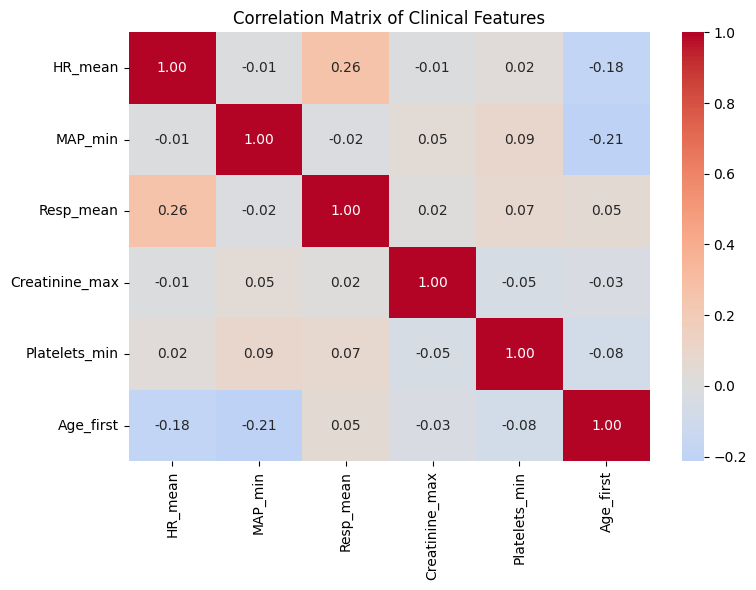

X shape: (40336, 6)
y shape: (40336,)

Missing values in X:


,Missing
HR_mean,5
MAP_min,104
Resp_mean,71
Creatinine_max,2049
Platelets_min,2577
Age_first,0



Outcome distribution:


,count
SepsisPatient,
0,37404
1,2932


Training set: (28235, 6)
Test set: (12101, 6)

Training outcome:
SepsisPatient
0    0.927324
1    0.072676
Name: proportion, dtype: float64

Test outcome:
SepsisPatient
0    0.927279
1    0.072721
Name: proportion, dtype: float64


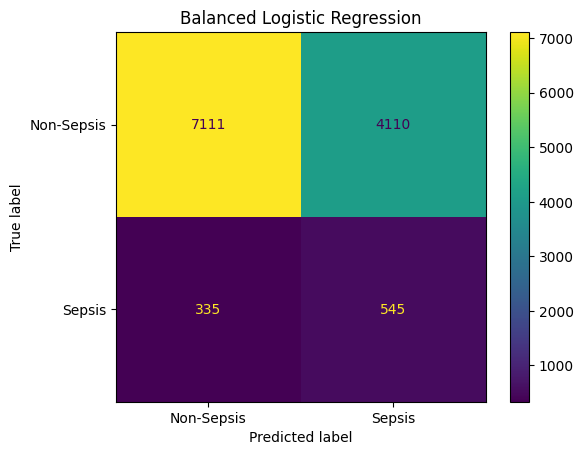

              precision    recall  f1-score   support

  Non-Sepsis       0.96      0.63      0.76     11221
      Sepsis       0.12      0.62      0.20       880

    accuracy                           0.63     12101
   macro avg       0.54      0.63      0.48     12101
weighted avg       0.89      0.63      0.72     12101



,Feature,Coefficient,Absolute_Coefficient
0,HR_mean,0.325114,0.325114
1,MAP_min,-0.312857,0.312857
3,Creatinine_max,0.179782,0.179782
2,Resp_mean,0.174200,0.174200
4,Platelets_min,-0.126402,0.126402
5,Age_first,0.033194,0.033194


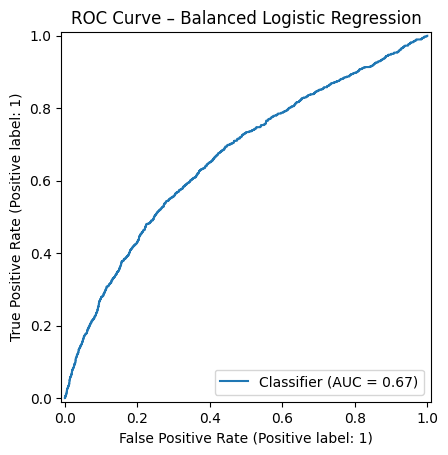

ROC-AUC: 0.666


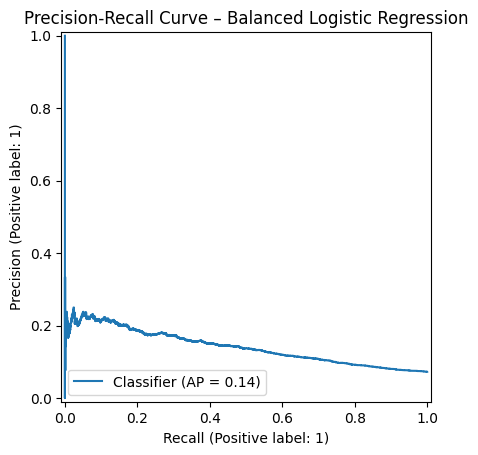

PR-AUC / Average Precision: 0.141


In [55]:
primary_features = [
    "HR_mean",
    "MAP_min",
    "Resp_mean",
    "Creatinine_max",
    "Platelets_min",
    "Age_first"
]

# =========================
# Correlation Matrix
# =========================
plt.figure(figsize=(8, 6))

sns.heatmap(
    dataset_agg[primary_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Clinical Features")
plt.tight_layout()
plt.show()


# =========================
# Feature and Target Selection
# =========================
target = "SepsisPatient"

X = dataset_agg[primary_features]
y = dataset_agg[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in X:")
display(X.isna().sum().to_frame("Missing"))

print("\nOutcome distribution:")
display(y.value_counts())


# =========================
# Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining outcome:")
print(y_train.value_counts(normalize=True))

print("\nTest outcome:")
print(y_test.value_counts(normalize=True))


# =========================
# Balanced Logistic Regression Pipeline
# =========================
balanced_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

balanced_pipeline.fit(X_train, y_train)


# =========================
# Predictions
# =========================
y_pred = balanced_pipeline.predict(X_test)

# Probability for Sepsis = 1
y_prob = balanced_pipeline.predict_proba(X_test)[:, 1]


# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Sepsis", "Sepsis"]
)

disp.plot()
plt.title("Balanced Logistic Regression")
plt.show()


# =========================
# Classification Report
# =========================
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Sepsis", "Sepsis"],
        zero_division=0
    )
)


# =========================
# Standardized Model Coefficients
# =========================
coefficients = pd.DataFrame({
    "Feature": primary_features,
    "Coefficient": balanced_pipeline
        .named_steps["classifier"]
        .coef_[0]
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(coefficients)


# =========================
# ROC Curve and ROC-AUC
# =========================
from sklearn import metrics

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve – Balanced Logistic Regression")
plt.show()

roc_auc = metrics.roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC: {roc_auc:.3f}")


# =========================
# Precision-Recall Curve and PR-AUC
# =========================
from sklearn.metrics import (
    PrecisionRecallDisplay,
    average_precision_score
)


PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Precision-Recall Curve – Balanced Logistic Regression")
plt.show()

pr_auc = average_precision_score(
    y_test,
    y_prob
)

print(f"PR-AUC / Average Precision: {pr_auc:.3f}")

## Primary Model – Summary and Interpretation

A multivariable logistic regression model was developed to examine the association between routinely available clinical characteristics and sepsis status.

### Model Development

The primary model included:

- Mean heart rate (`HR_mean`)
- Minimum mean arterial pressure (`MAP_min`)
- Mean respiratory rate (`Resp_mean`)
- Maximum creatinine (`Creatinine_max`)
- Minimum platelet count (`Platelets_min`)
- Age (`Age_first`)

Lactate was deliberately excluded from the primary model because it was unavailable in approximately 69% of patients and showed substantial outcome-dependent missingness. It was therefore reserved for a secondary analysis.

Missing values in the primary predictors were handled using median imputation. Continuous predictors were standardized before logistic regression. Both preprocessing steps were incorporated into a scikit-learn pipeline to ensure that imputation and scaling parameters were learned exclusively from the training data.

The dataset was split into training (70%) and test (30%) sets using stratification to preserve the approximately 7.3% prevalence of sepsis in both subsets.

### Class Imbalance

The cohort showed substantial class imbalance, with approximately 7.3% of patients classified as having sepsis.

An initially unweighted logistic regression model achieved approximately 93% accuracy but failed to identify any sepsis patients at the default classification threshold. This demonstrated that accuracy was misleading in this imbalanced dataset.

Class weighting was therefore introduced using `class_weight="balanced"`.

The balanced model substantially increased sensitivity for sepsis:

- **Sepsis recall:** 0.62
- **Sepsis precision:** 0.12
- **Sepsis F1-score:** 0.20
- **Overall accuracy:** 0.63

The improvement in sensitivity was accompanied by a substantial increase in false-positive classifications, illustrating the trade-off between detecting more sepsis patients and generating more false alarms.

### Model Discrimination

The balanced logistic regression model achieved:

- **ROC-AUC: 0.67**
- **Average Precision (PR): 0.14**

The ROC-AUC indicates modest discrimination between patients with and without sepsis.

Given the low prevalence of sepsis, the precision-recall analysis provides additional insight into performance for the minority class. Although the average precision exceeded the approximate prevalence-based baseline (~0.07), overall precision remained limited.

Therefore, the selected clinical characteristics contain discriminatory information but are insufficient for highly accurate classification of sepsis status on their own.

### Multivariable Associations

Standardized logistic regression coefficients showed the strongest associations for:

| Feature | Standardized coefficient | Direction of association with sepsis |
|---|---:|---|
| HR_mean | +0.325 | Higher heart rate |
| MAP_min | -0.313 | Lower minimum MAP |
| Creatinine_max | +0.180 | Higher creatinine |
| Resp_mean | +0.174 | Higher respiratory rate |
| Platelets_min | -0.126 | Lower platelet count |
| Age_first | +0.033 | Minimal association |

Heart rate and minimum MAP showed the strongest multivariable associations with sepsis status. Creatinine, respiratory rate, and platelet count showed smaller associations, while age contributed little to the model.

The direction and relative magnitude of these associations were broadly consistent with the preceding univariate analyses.

### Clinical Interpretation

Overall, patients with sepsis showed a pattern of greater physiological disturbance, including higher heart rate and respiratory rate, lower minimum MAP and platelet counts, and higher maximum creatinine.

However, statistically and clinically plausible associations did not translate into strong predictive discrimination. This distinction is important: a variable may differ significantly between groups or remain independently associated with sepsis without being sufficient to accurately classify individual patients.

The model should therefore be interpreted as an exploratory patient-level analysis of clinical characteristics associated with sepsis status rather than as a validated clinical prediction model.